# CONEXIÓN CON DynamoDB: POBLACIÓN DE DATOS y CONSULTAS

In [1]:
# ============================================================
# ACME - Carga de datos de prueba y consultas en DynamoDB
# Tabla: acme-dydb-sensores
# ============================================================

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
from decimal import Decimal

random.seed(42) # para reproducibilidad

print('Bibliotecas cargadas')

Bibliotecas cargadas


## 1. Generación de Lecturas simuladas para Sensores de Humedad de Suelo TDR

### 1.1 Funciones auxiliares para la generación de lecturas de sensores

In [2]:
INTERVALO = timedelta(minutes=30)         # los sensores emiten cada 30 minutos
INICIO = datetime(2026, 8, 1, 0, 0, 0)    # fecha/hora base de referencia
RANGO_VALIDO = (0, 100)                   # % de humedad físicamente posible
UNIDAD = "%"
VALOR_NORMAL_MAXIMO = 45 # %
DIAS_MAX_EXPIRAR = 100 # días


def es_valida(valor):
    '''Una lectura es válida si está dentro del rango físicamente posible.'''
    return RANGO_VALIDO[0] <= valor <= RANGO_VALIDO[1]


def generar_timestamps(inicio, duracion_horas):
    '''Genera una lista de timestamps espaciados por INTERVALO, cubriendo duracion_horas.'''
    total_lecturas = int(duracion_horas * 60 / (INTERVALO.total_seconds() / 60))
    return [inicio + i * INTERVALO for i in range(total_lecturas)]


def valor_normal():
    '''Lectura de humedad dentro de un rango operativo normal para el tipo de proyecto.'''
    return round(random.uniform(20, VALOR_NORMAL_MAXIMO), 1)


def valor_anormal_aunque_plausible():
    '''Lectura de humedad dentro de un rango posible pero que refleja problemas 
    para el objeto bajo monitoreo.'''
    return round(random.uniform(VALOR_NORMAL_MAXIMO + 1e-5, RANGO_VALIDO[1]), 1)


def valor_fuera_de_rango():
    '''Lectura claramente imposible, para simular una falla abrupta y sostenida del sensor.'''
    return round(random.uniform(RANGO_VALIDO[1] + 1e-5, 180), 1)


def crear_item(sensor_id, 
               proyecto_id, 
               suscripcion_id, 
               tipo_sensor_id, 
               ts, 
               valor, dias_max_expirar=DIAS_MAX_EXPIRAR):
    
    expira_en = int((ts + timedelta(days=dias_max_expirar)).timestamp())
    return {
        'sensor_id': sensor_id,
        'timestamp': ts.strftime('%Y-%m-%dT%H:%M:%SZ'),
        'proyecto_id': proyecto_id,
        'suscripcion_id': suscripcion_id,
        'tipo_sensor_id': tipo_sensor_id,
        'valor': Decimal(str(valor)),
        'unidad_medida': UNIDAD,
        'lectura_valida': es_valida(valor),
        'expira_en': expira_en
    }

### 1.2 Generación de lecturas de sensores para Proyecto 1    

Se contempla:  
- 1 suscripción (id 101), 2 sensores (ids 1 y 2), 2 días de lecturas.
- Sensor 1: siempre válido.
- Sensor 2: falla abruptamente a mediodía del segundo día.

In [3]:
ventana_ts = generar_timestamps(INICIO, 48)  # INICIO = datetime(2026, 8, 1, 0, 0, 0) 

# ============================================================
# Sensor 1 - siempre válido
# ============================================================

items_s1 = []
for ts in ventana_ts:
    items_s1.append(
        crear_item('1', proyecto_id='1', suscripcion_id='101', tipo_sensor_id='1', ts=ts, valor=valor_normal())
    )
len_s1 = len(items_s1)
print(f'{len_s1} Lecturas simuladas para el sensor 1, tipo 1, proyecto 1, suscripción 101.')


# ============================================================
# Sensor 2 - falla abruptamente a mediodía del segundo día
# ============================================================

inicio_falla_sensor = INICIO + timedelta(hours=24+12)  # mediodía del segundo día

items_s2 = []
for ts in ventana_ts:
    if ts < inicio_falla_sensor:
        valor = valor_normal()
    else:
        valor = valor_fuera_de_rango()
    items_s2.append(
        crear_item('2', proyecto_id='1', suscripcion_id='101', tipo_sensor_id='1', ts=ts, valor=valor)
    )
len_s2 = len(items_s2)
print(f'{len_s2} Lecturas simuladas para el sensor 2, tipo 1, proyecto 1, suscripción 101.')

96 Lecturas simuladas para el sensor 1, tipo 1, proyecto 1, suscripción 101.
96 Lecturas simuladas para el sensor 2, tipo 1, proyecto 1, suscripción 101.


In [4]:
# chequeo de lecturas correctamente generadas

print('Lecturas para sensor 1')
display(pd.DataFrame(items_s1).head())
print()
print('Lecturas para sensor 2')
display(pd.DataFrame(items_s2).tail())

Lecturas para sensor 1


,sensor_id,timestamp,proyecto_id,suscripcion_id,tipo_sensor_id,valor,unidad_medida,lectura_valida,expira_en
0,1,2026-08-01T00:00:00Z,1,101,1,36.0,%,True,1794193200
1,1,2026-08-01T00:30:00Z,1,101,1,20.6,%,True,1794195000
2,1,2026-08-01T01:00:00Z,1,101,1,26.9,%,True,1794196800
3,1,2026-08-01T01:30:00Z,1,101,1,25.6,%,True,1794198600
4,1,2026-08-01T02:00:00Z,1,101,1,38.4,%,True,1794200400



Lecturas para sensor 2


,sensor_id,timestamp,proyecto_id,suscripcion_id,tipo_sensor_id,valor,unidad_medida,lectura_valida,expira_en
91,2,2026-08-02T21:30:00Z,1,101,1,119.9,%,False,1794357000
92,2,2026-08-02T22:00:00Z,1,101,1,115.2,%,False,1794358800
93,2,2026-08-02T22:30:00Z,1,101,1,135.9,%,False,1794360600
94,2,2026-08-02T23:00:00Z,1,101,1,133.8,%,False,1794362400
95,2,2026-08-02T23:30:00Z,1,101,1,122.3,%,False,1794364200


### 1.3 Generación de lecturas de sensores para Proyecto 2     

Se contempla: 
- 2 suscripciones (ids 201 y 202), 2 días de lecturas.
- Suscripción id 201: 3 sensores (ids 3, 4 y 5).
    - Sensor 3: siempre válido.
    - Sensor 4: siempre válido.
    - Sensor 5: siempre válido, considerando inicio de lecturas anormales (aunque plausibles) desde las 08:00 hrs del segundo día.
- Suscripción id 202: 1 sensor (id 6)
    - Sensor 6: falla abruptamente a las 22:00 horas del segundo día.

In [5]:
ventana_ts = generar_timestamps(INICIO, 48)  # INICIO = datetime(2026, 8, 1, 0, 0, 0) 

# ============================================================
# Sensor 3 - suscripción 201 - siempre válido
# ============================================================

items_s3 = []
for ts in ventana_ts:
    items_s3.append(
        crear_item('3', proyecto_id='2', suscripcion_id='201', tipo_sensor_id='1', ts=ts, valor=valor_normal())
    )
len_s3 = len(items_s3)
print(f'{len_s3} Lecturas simuladas para el sensor 3, tipo 1, proyecto 2, suscripción 201.')


# ============================================================
# Sensor 4 - suscripción 201 - siempre válido
# ============================================================

items_s4 = []
for ts in ventana_ts:
    items_s4.append(
        crear_item('4', proyecto_id='2', suscripcion_id='201', tipo_sensor_id='1', ts=ts, valor=valor_normal())
    )
len_s4 = len(items_s4)
print(f'{len_s4} Lecturas simuladas para el sensor 4, tipo 1, proyecto 2, suscripción 201.')


# =========================================================================================================
# Sensor 5 - suscripción 201 - con lecturas anormales pero plausibles desde las 08:00 hrs del segundo día
# =========================================================================================================

inicio_anomalia = INICIO + timedelta(hours=24+8)  # 08:00 hrs del segundo día

items_s5 = []
for ts in ventana_ts:
    if ts < inicio_anomalia:
        valor = valor_normal()
    else:
        valor = valor_anormal_aunque_plausible()
    items_s5.append(
        crear_item('5', proyecto_id='2', suscripcion_id='201', tipo_sensor_id='1', ts=ts, valor=valor)
    )
len_s5 = len(items_s5)
print(f'{len_s5} Lecturas simuladas para el sensor 5, tipo 1, proyecto 2, suscripción 201.')


# ===============================================================
# Sensor 6 - falla abruptamente a las 22:00 hrs del segundo día
# ===============================================================

inicio_falla_sensor = INICIO + timedelta(hours=24+22)  # 22:00 hrs del segundo día

items_s6 = []
for ts in ventana_ts:
    if ts < inicio_falla_sensor:
        valor = valor_normal()
    else:
        valor = valor_fuera_de_rango()
    items_s6.append(
        crear_item('6', proyecto_id='2', suscripcion_id='202', tipo_sensor_id='1', ts=ts, valor=valor)
    )
len_s6 = len(items_s6)
print(f'{len_s6} Lecturas simuladas para el sensor 6, tipo 1, proyecto 2, suscripción 202.')

96 Lecturas simuladas para el sensor 3, tipo 1, proyecto 2, suscripción 201.
96 Lecturas simuladas para el sensor 4, tipo 1, proyecto 2, suscripción 201.
96 Lecturas simuladas para el sensor 5, tipo 1, proyecto 2, suscripción 201.
96 Lecturas simuladas para el sensor 6, tipo 1, proyecto 2, suscripción 202.


In [6]:
# chequeo de lecturas correctamente generadas

print('Lecturas para sensor 3')
display(pd.DataFrame(items_s3).head())
print()
print('Lecturas para sensor 4')
display(pd.DataFrame(items_s4).head())
print()
print('Lecturas para sensor 5')
display(pd.DataFrame(items_s5).tail())
print()
print('Lecturas para sensor 6')
display(pd.DataFrame(items_s6).tail())

Lecturas para sensor 3


,sensor_id,timestamp,proyecto_id,suscripcion_id,tipo_sensor_id,valor,unidad_medida,lectura_valida,expira_en
0,3,2026-08-01T00:00:00Z,2,201,1,26.2,%,True,1794193200
1,3,2026-08-01T00:30:00Z,2,201,1,43.1,%,True,1794195000
2,3,2026-08-01T01:00:00Z,2,201,1,31.1,%,True,1794196800
3,3,2026-08-01T01:30:00Z,2,201,1,41.5,%,True,1794198600
4,3,2026-08-01T02:00:00Z,2,201,1,33.8,%,True,1794200400



Lecturas para sensor 4


,sensor_id,timestamp,proyecto_id,suscripcion_id,tipo_sensor_id,valor,unidad_medida,lectura_valida,expira_en
0,4,2026-08-01T00:00:00Z,2,201,1,30.6,%,True,1794193200
1,4,2026-08-01T00:30:00Z,2,201,1,26.9,%,True,1794195000
2,4,2026-08-01T01:00:00Z,2,201,1,20.1,%,True,1794196800
3,4,2026-08-01T01:30:00Z,2,201,1,39.3,%,True,1794198600
4,4,2026-08-01T02:00:00Z,2,201,1,35.9,%,True,1794200400



Lecturas para sensor 5


,sensor_id,timestamp,proyecto_id,suscripcion_id,tipo_sensor_id,valor,unidad_medida,lectura_valida,expira_en
91,5,2026-08-02T21:30:00Z,2,201,1,94.8,%,True,1794357000
92,5,2026-08-02T22:00:00Z,2,201,1,77.1,%,True,1794358800
93,5,2026-08-02T22:30:00Z,2,201,1,83.3,%,True,1794360600
94,5,2026-08-02T23:00:00Z,2,201,1,92.1,%,True,1794362400
95,5,2026-08-02T23:30:00Z,2,201,1,87.1,%,True,1794364200



Lecturas para sensor 6


,sensor_id,timestamp,proyecto_id,suscripcion_id,tipo_sensor_id,valor,unidad_medida,lectura_valida,expira_en
91,6,2026-08-02T21:30:00Z,2,202,1,30.9,%,True,1794357000
92,6,2026-08-02T22:00:00Z,2,202,1,158.7,%,False,1794358800
93,6,2026-08-02T22:30:00Z,2,202,1,177.2,%,False,1794360600
94,6,2026-08-02T23:00:00Z,2,202,1,121.6,%,False,1794362400
95,6,2026-08-02T23:30:00Z,2,202,1,164.7,%,False,1794364200


### 1.4 Resumen

In [7]:
total_lecturas_simuladas = len_s1 + len_s2 + len_s3 + len_s4 + len_s5 + len_s6

print(f'Total lecturas simuladas de sensores para los dos proyectos = {total_lecturas_simuladas}')
print()
print(f'  - {len_s1} Lecturas simuladas para el sensor 1, tipo 1, proyecto 1, suscripción 101.')
print(f'  - {len_s2} Lecturas simuladas para el sensor 2, tipo 1, proyecto 1, suscripción 101.')
print(f'  - {len_s3} Lecturas simuladas para el sensor 3, tipo 1, proyecto 2, suscripción 201.')
print(f'  - {len_s4} Lecturas simuladas para el sensor 4, tipo 1, proyecto 2, suscripción 201.')
print(f'  - {len_s5} Lecturas simuladas para el sensor 5, tipo 1, proyecto 2, suscripción 201.')
print(f'  - {len_s6} Lecturas simuladas para el sensor 6, tipo 1, proyecto 2, suscripción 202.')

Total lecturas simuladas de sensores para los dos proyectos = 576

  - 96 Lecturas simuladas para el sensor 1, tipo 1, proyecto 1, suscripción 101.
  - 96 Lecturas simuladas para el sensor 2, tipo 1, proyecto 1, suscripción 101.
  - 96 Lecturas simuladas para el sensor 3, tipo 1, proyecto 2, suscripción 201.
  - 96 Lecturas simuladas para el sensor 4, tipo 1, proyecto 2, suscripción 201.
  - 96 Lecturas simuladas para el sensor 5, tipo 1, proyecto 2, suscripción 201.
  - 96 Lecturas simuladas para el sensor 6, tipo 1, proyecto 2, suscripción 202.


## 2. Ingesta de Datos a Base noSQL

### 2.1 Conexión a la base

In [8]:
# ============================================================
# Conexión a DynamoDb
# ============================================================

# --- Requisitos ---
# pip install boto3
# Credenciales configuradas (aws configure, o variables de entorno
# AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY / AWS_SESSION_TOKEN obtenidas desde AWS Academy)

import json
import boto3
from boto3.dynamodb.conditions import Key, Attr
from botocore.exceptions import ClientError

AWS_ACCESS_KEY_ID = "ASIAW..."
AWS_SECRET_ACCESS_KEY = "+DVE+LGo..."
AWS_SESSION_TOKEN = "IQoJb3JpZWVpgIe3fh+4V..."
REGION = "us-east-1"  

# conexión a sesión con las credenciales 
session = boto3.Session(
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    aws_session_token=AWS_SESSION_TOKEN,
    region_name=REGION
)

# conexión a dynamo dentro de la sesión
dynamodb = session.resource('dynamodb')

nombre_tabla = 'acme-dydb-sensores'
table = dynamodb.Table(nombre_tabla)

# prueba de conexión
try:
    print(f"Intentando conectar a la tabla '{nombre_tabla}'...")
    response = table.scan(Limit=5) 
    print("¡Conexión exitosa!")
    print("Elementos encontrados:", response.get('Items', []))
    
except Exception as e:
    print(f"Error de conexión: {e}")

Intentando conectar a la tabla 'acme-dydb-sensores'...
¡Conexión exitosa!
Elementos encontrados: []


### 2.2 Función auxiliar para la ingesta de datos

In [9]:
def insertar_lote(items, descripcion=""):
    '''
    Inserta una lista de ítems usando batch_writer (maneja reintentos y lotes de 25, por defecto).
    Devuelve el tiempo (s) empleado en la ingesta de datos.
    '''
    ti = datetime.now()
    with table.batch_writer() as batch:
        for item in items:
            batch.put_item(Item=item) # No envía inmediatamente, acumula en memoria 25 elementos y luego los envía
    tf = datetime.now()
    delta_t = (tf-ti).total_seconds()
    print(f"[{descripcion}] Insertadas {len(items)} lecturas en {delta_t:.1f} segundos")
    return delta_t

### 2.3 Ingesta

In [10]:
# ============================================================
# Ingesta de datos
# ============================================================

dt1 = insertar_lote(items_s1, "Proyecto 1 - Suscripción 101")
dt2 = insertar_lote(items_s2, "Proyecto 1 - Suscripción 101")
dt3 = insertar_lote(items_s3, "Proyecto 2 - Suscripción 201")
dt4 = insertar_lote(items_s4, "Proyecto 2 - Suscripción 201")
dt5 = insertar_lote(items_s5, "Proyecto 2 - Suscripción 201")
dt6 = insertar_lote(items_s6, "Proyecto 2 - Suscripción 202")

[Proyecto 1 - Suscripción 101] Insertadas 96 lecturas en 0.7 segundos
[Proyecto 1 - Suscripción 101] Insertadas 96 lecturas en 0.6 segundos
[Proyecto 2 - Suscripción 201] Insertadas 96 lecturas en 0.7 segundos
[Proyecto 2 - Suscripción 201] Insertadas 96 lecturas en 0.9 segundos
[Proyecto 2 - Suscripción 201] Insertadas 96 lecturas en 0.7 segundos
[Proyecto 2 - Suscripción 202] Insertadas 96 lecturas en 0.7 segundos


In [11]:
dt = dt1 + dt2 + dt3 + dt3 + dt4 + dt5 + dt6
print(f"Carga de datos completa: {total_lecturas_simuladas} lecturas ingresadas en {dt:.1f} segundos")

Carga de datos completa: 576 lecturas ingresadas en 5.0 segundos


## 3. CONSULTAS

### 3.1 Consulta 1  

Verificar que los elementos hayan quedado ingresados

In [12]:
ID_SENSOR_A_BUSCAR = '1' 

try:
    print(f"Consultando últimas lecturas para el sensor: {ID_SENSOR_A_BUSCAR}...")
    response = table.query(
        KeyConditionExpression=Key('sensor_id').eq(ID_SENSOR_A_BUSCAR),
        ScanIndexForward=False,  # orden descendente
        Limit=5                  # últimas 5 lecturas para no saturar la pantalla
    )
    
    lecturas = response.get('Items', [])
    
    if lecturas:
        print(f"\n¡Conexión exitosa! Las {len(lecturas)} lecturas más recientes son:")
        display(pd.DataFrame(lecturas))
    else:
        print(f"\nNo se encontraron datos para el sensor '{ID_SENSOR_A_BUSCAR}'.")

except Exception as e:
    print(f"\nOcurrió un error: {e}")

Consultando últimas lecturas para el sensor: 1...

¡Conexión exitosa! Las 5 lecturas más recientes son:


,valor,suscripcion_id,sensor_id,unidad_medida,lectura_valida,tipo_sensor_id,expira_en,proyecto_id,timestamp
0,29.5,101,1,%,True,1,1794364200,1,2026-08-02T23:30:00Z
1,21.6,101,1,%,True,1,1794362400,1,2026-08-02T23:00:00Z
2,30.6,101,1,%,True,1,1794360600,1,2026-08-02T22:30:00Z
3,39.8,101,1,%,True,1,1794358800,1,2026-08-02T22:00:00Z
4,35.7,101,1,%,True,1,1794357000,1,2026-08-02T21:30:00Z


### 3.2 Consulta 2   

Del total de sensores instalados en todos los proyectos, ¿cuáles sensores están fallando dentro del último día de lecturas registrado?

In [13]:
def sensores_fallando_dentro_ventana_tiempo_directo(sensor_ids, inicio_ventana, fin_ventana):

    # formatear las fechas a String ISO-8601
    inicio_str = inicio_ventana.strftime('%Y-%m-%dT%H:%M:%SZ')
    fin_str = fin_ventana.strftime('%Y-%m-%dT%H:%M:%SZ')

    registros = []
    
    for sensor_id in sensor_ids:
        respuesta = table.query(
            KeyConditionExpression=(
                Key('sensor_id').eq(sensor_id) & 
                Key('timestamp').between(inicio_str, fin_str)
            ),
            FilterExpression=Attr('lectura_valida').eq(False)
        )
        
        for item in respuesta.get('Items', []):
            registros.append({
                'sensor_id': item['sensor_id'],
                'tipo_sensor_id': item.get('tipo_sensor_id', 'N/A'),  # .get() evita errores si falta un atributo
                'proyecto_id': item.get('proyecto_id', 'N/A'),
                'suscripcion_id': item.get('suscripcion_id', 'N/A'),
            })

    if not registros:
        print("No se encontraron lecturas no válidas.")
        return 

    df = pd.DataFrame(registros)
    resumen = df.groupby(['proyecto_id', 'suscripcion_id', 'sensor_id']).agg(
        lecturas_invalidas=('sensor_id', 'count')
    ).reset_index()
    
    return resumen


# En un escenario real, esta lista vendría de la tabla `sensores` en RDS
ids_sensores_activos = ['1', '2', '3', '4', '5', '6']

inicio_ventana = INICIO + timedelta(hours=24)  # INICIO = datetime(2026, 8, 1, 0, 0, 0)  
fin_ventana    = INICIO + timedelta(hours=48)

resumen_fallas = sensores_fallando_dentro_ventana_tiempo_directo(ids_sensores_activos, inicio_ventana, fin_ventana)
resumen_fallas

,proyecto_id,suscripcion_id,sensor_id,lecturas_invalidas
0,1,101,2,24
1,2,202,6,4


### 3.3 Consulta 3   

Del total de proyectos, ¿cuáles sensores están fallando dentro del último día de lecturas registrado?

A escala masiva, siempre es mejor restringir el proyecto antes de hacer la consulta como en *Consulta 1*. En DynamoDB, la regla de oro para el rendimiento y los costos es filtrar lo más temprano posible mediante las llaves (KeyConditionExpression).

In [14]:
def sensores_fallando_dentro_ventana_tiempo_filtrado_por_proyecto(proyecto_ids, inicio_ventana, fin_ventana):
    
    # formatear las fechas a String ISO-8601
    inicio_str = inicio_ventana.strftime('%Y-%m-%dT%H:%M:%SZ')
    fin_str    = fin_ventana.strftime('%Y-%m-%dT%H:%M:%SZ')

    registros = []
    
    # iterar sobre id_proyecto, ya que son la PK del Índice
    for proyecto_id in proyecto_ids:
        respuesta = table.query(
            IndexName='proyecto-timestamp-index',
            KeyConditionExpression=(
                Key('proyecto_id').eq(proyecto_id) & 
                Key('timestamp').between(inicio_str, fin_str)
            ),
            # filtrar que la lectura sea inválida y que pertenezca a los sensores buscados
            FilterExpression=Attr('lectura_valida').eq(False)
        )
        
        for item in respuesta.get('Items', []):
            registros.append({
                'sensor_id': item['sensor_id'],
                'tipo_sensor_id': item.get('tipo_sensor_id', 'N/A'), # .get() evita errores si falta un atributo
                'proyecto_id': item['proyecto_id'],
                'suscripcion_id': item.get('suscripcion_id', 'N/A'),
            })

    if not registros:
        print("No se encontraron lecturas no válidas.")
        return

    df = pd.DataFrame(registros)
    resumen = df.groupby(['proyecto_id', 'suscripcion_id', 'sensor_id']).agg(
        lecturas_invalidas=('sensor_id', 'count')
    ).reset_index()
    
    return resumen


# En un escenario real, esta lista vendría de la tabla `proyectos` en RDS
ids_proyectos_activos = ['1', '2'] 

inicio_ventana = INICIO + timedelta(hours=24)  # INICIO = datetime(2026, 8, 1, 0, 0, 0)  
fin_ventana    = INICIO + timedelta(hours=48)

resumen_fallas = sensores_fallando_dentro_ventana_tiempo_filtrado_por_proyecto(ids_proyectos_activos, inicio_ventana, fin_ventana)
resumen_fallas

,proyecto_id,suscripcion_id,sensor_id,lecturas_invalidas
0,1,101,2,24
1,2,202,6,4


### 3.4 Consulta 4  

Para un proyecto en particular, ¿a partir de qué momento alguno de sus sensores comenzó a entregar lecturas anómalas dentro del último día?

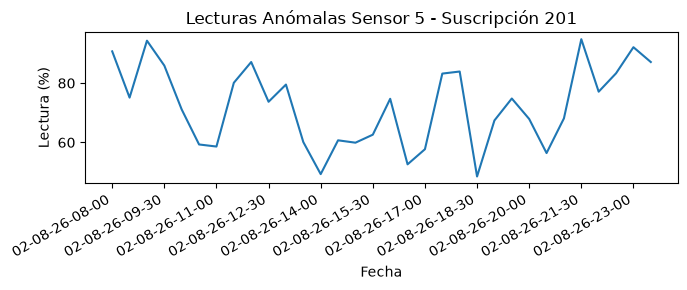

In [15]:
import matplotlib.pyplot as plt

def sensores_indicando_anomalias_en_monitoreo(proyecto_id, inicio_ventana, fin_ventana, valor_normal_maximo=VALOR_NORMAL_MAXIMO):

    # formatear las fechas a String ISO-8601
    inicio_str = inicio_ventana.strftime('%Y-%m-%dT%H:%M:%SZ')
    fin_str    = fin_ventana.strftime('%Y-%m-%dT%H:%M:%SZ')

    registros = []
    
    respuesta = table.query(
        IndexName='proyecto-timestamp-index',
        KeyConditionExpression=(
            Key('proyecto_id').eq(proyecto_id) & 
            Key('timestamp').between(inicio_str, fin_str)
        ),
        # filtrar que la lectura sea válida y que pertenezca a los sensores buscados
        FilterExpression=(
            Attr('lectura_valida').eq(True) & 
            Attr('valor').gt(valor_normal_maximo)
        )
    )
    
    for item in respuesta.get('Items', []):
        registros.append({
            'sensor_id': item['sensor_id'],
            'suscripcion_id': item.get('suscripcion_id', 'N/A'),
            'lectura_anomala': float(item.get('valor', 'N/A')),
            'fecha': item.get('timestamp', 'N/A'),
            'unidad_medida': item.get('unidad_medida', 'N/A'),
        })

    if not registros:
        print("No se encontraron lecturas válidas.")
        return

    df = pd.DataFrame(registros)
    df['fecha'] = pd.to_datetime(df['fecha']).dt.strftime('%d-%m-%y-%H-%M')
    resumen = df.sort_values(['suscripcion_id', 'sensor_id'])

    return resumen


id_proyecto = '2'
inicio_ventana = INICIO + timedelta(hours=24)  # INICIO = datetime(2026, 8, 1, 0, 0, 0)  
fin_ventana    = INICIO + timedelta(hours=48)

resumen_anomalos = sensores_indicando_anomalias_en_monitoreo(id_proyecto, inicio_ventana, fin_ventana)

suscripciones_unicas = resumen_anomalos.suscripcion_id.unique()

for sus in suscripciones_unicas:
    dfa = resumen_anomalos[resumen_anomalos.suscripcion_id==sus]
    sensores_anomalos_unicos = dfa.sensor_id.unique()
    for sen in sensores_anomalos_unicos:
        unidad = dfa.unidad_medida.unique()[0]
       
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.plot(dfa.fecha, dfa.lectura_anomala)

        paso = 3
        ax.set_xticks(dfa.fecha.iloc[::paso])
        fig.autofmt_xdate()

        ax.set_title(f'Lecturas Anómalas Sensor {sen} - Suscripción {sus}')
        ax.set_xlabel('Fecha')
        ax.set_ylabel(f'Lectura ({unidad})')

        plt.tight_layout()
        plt.show()

**Observaciones:**  
- **Uso de GSI**. La consulta 2 tiene que iterar manualmente en un ciclo for buscando sensor por sensor (fuerza bruta en la tabla principal), mientras que la consulta 3 ataca directamente al índice proyecto-timestamp-index enviando el proyecto_id en la KeyConditionExpression, lo que reduce el consumo de RCU (unidades de capacidad de lectura) de forma masiva.
- **Uso de filtros avanzados:** La Consulta 4 modela una lógica impecable para dashboards, combinando una consulta de llave por proyecto_id en el GSI con una FilterExpression matemática que aísla solo lecturas válidas que superen el umbral de alerta (valor > valor_normal_maximo). El gráfico resultante para el Sensor 5 de la Suscripción 201 demuestra que el pipeline de datos genera anomalías plausibles de forma correcta.